# 🌍 Análisis de Temperatura Global y Cambio Climático

**Autor:** Oscar Mauricio Montenegro  
**Fecha:** Abril 2026  
**Dataset:** Berkeley Earth Surface Temperature (1850-2015)

---

## Objetivo

Analizar tendencias de temperatura global, cuantificar aceleración del calentamiento, e identificar los años y décadas más cálidos en el registro histórico.

## Metodología

1. Carga y exploración de datos
2. Limpieza y filtrado (1850+)
3. Cálculo de anomalías térmicas
4. Análisis por décadas y periodos
5. Visualizaciones profesionales

---

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [34]:
# Cargar el dataset
df = pd.read_csv('data/GlobalTemperatures.csv')

# Ver primeras filas
print("📊 Primeras 5 filas del dataset:")
df.head()

📊 Primeras 5 filas del dataset:


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Exploración básica del dataset
print("📏 Dimensiones del dataset:")
print(f"   Filas: {df.shape[0]:,}")
print(f"   Columnas: {df.shape[1]}")
print("\n📋 Columnas disponibles:")
print(df.columns.tolist())
print("\n🔍 Información del dataset:")
df.info()

📏 Dimensiones del dataset:
   Filas: 3,192
   Columnas: 9

📋 Columnas disponibles:
['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty', 'LandMaxTemperature', 'LandMaxTemperatureUncertainty', 'LandMinTemperature', 'LandMinTemperatureUncertainty', 'LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty']

🔍 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   object 
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperat

In [36]:
# Ver estadísticas descriptivas
print("📈 Estadísticas descriptivas:")
df.describe()

📈 Estadísticas descriptivas:


,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
count,3180.000000,3180.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,8.374731,0.938468,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
std,4.381310,1.096440,4.309579,0.583203,4.155835,0.445838,1.274093,0.073587
min,-2.080000,0.034000,5.900000,0.044000,-5.407000,0.045000,12.475000,0.042000
25%,4.312000,0.186750,10.212000,0.142000,-1.334500,0.155000,14.047000,0.063000
50%,8.610500,0.392000,14.760000,0.252000,2.949500,0.279000,15.251000,0.122000
75%,12.548250,1.419250,18.451500,0.539000,6.778750,0.458250,16.396250,0.151000
max,19.021000,7.880000,21.320000,4.373000,9.715000,3.498000,17.611000,0.457000


In [37]:
print("📅 Rango de fechas en el dataset:")
print(f"   Fecha inicial: {df['dt'].min()}")
print(f"   Fecha final: {df['dt'].max()}")
print(f"   Total de años: {df.shape[0] / 12:.0f} años (datos mensuales)")

📅 Rango de fechas en el dataset:
   Fecha inicial: 1750-01-01
   Fecha final: 2015-12-01
   Total de años: 266 años (datos mensuales)


In [38]:
# Convertir columna 'dt' a formato fecha
df['dt'] = pd.to_datetime(df['dt'])

# Crear columnas útiles para análisis
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df['Decade'] = (df['Year'] // 10) * 10  # Agrupar por décadas

print("✅ Fechas convertidas correctamente")
print("\n📋 Nuevas columnas creadas:")
print(df[['dt', 'Year', 'Month', 'Decade']].head())

✅ Fechas convertidas correctamente

📋 Nuevas columnas creadas:
          dt  Year  Month  Decade
0 1750-01-01  1750      1    1750
1 1750-02-01  1750      2    1750
2 1750-03-01  1750      3    1750
3 1750-04-01  1750      4    1750
4 1750-05-01  1750      5    1750


In [39]:
# Verificar valores nulos (datos faltantes)
print("🔍 Datos faltantes por columna:")
missing_data = df.isnull().sum()
print(missing_data)

# Calcular porcentaje de datos faltantes
print("\n📊 Porcentaje de datos faltantes:")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.round(2))

🔍 Datos faltantes por columna:
dt                                              0
LandAverageTemperature                         12
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200
LandMinTemperature                           1200
LandMinTemperatureUncertainty                1200
LandAndOceanAverageTemperature               1200
LandAndOceanAverageTemperatureUncertainty    1200
Year                                            0
Month                                           0
Decade                                          0
dtype: int64

📊 Porcentaje de datos faltantes:
dt                                            0.00
LandAverageTemperature                        0.38
LandAverageTemperatureUncertainty             0.38
LandMaxTemperature                           37.59
LandMaxTemperatureUncertainty                37.59
LandMinTemperature                           37.59
LandMinTemperatu

In [40]:
# Filtrar datos desde 1850 en adelante (datos más confiables)
df_clean = df[df['Year'] >= 1850].copy()

print(f"📉 Dataset original: {len(df):,} filas")
print(f"📈 Dataset filtrado (1850+): {len(df_clean):,} filas")
print(f"   Años analizados: {df_clean['Year'].min()} - {df_clean['Year'].max()}")

# Usar solo la columna de temperatura tierra+océano (más completa)
df_clean = df_clean[['dt', 'Year', 'Month', 'Decade', 'LandAndOceanAverageTemperature']].copy()

# Renombrar para facilidad
df_clean.rename(columns={'LandAndOceanAverageTemperature': 'Temperature'}, inplace=True)

# Eliminar filas con temperatura nula
df_clean = df_clean.dropna(subset=['Temperature'])

print(f"\n✅ Dataset limpio: {len(df_clean):,} filas")
print("\n📋 Primeras filas del dataset limpio:")
df_clean.head()

📉 Dataset original: 3,192 filas
📈 Dataset filtrado (1850+): 1,992 filas
   Años analizados: 1850 - 2015

✅ Dataset limpio: 1,992 filas

📋 Primeras filas del dataset limpio:


,dt,Year,Month,Decade,Temperature
1200,1850-01-01,1850,1,1850,12.833
1201,1850-02-01,1850,2,1850,13.588
1202,1850-03-01,1850,3,1850,14.043
1203,1850-04-01,1850,4,1850,14.667
1204,1850-05-01,1850,5,1850,15.507


In [41]:
# Agrupar por año (promedio anual)
df_annual = df_clean.groupby('Year')['Temperature'].mean().reset_index()

print(f"📊 Dataset anual creado: {len(df_annual)} años")
print("\n📋 Primeras filas:")
print(df_annual.head())
print("\n📋 Últimas filas:")
print(df_annual.tail())

# Calcular anomalías (diferencia vs. periodo base 1850-1900)
baseline_temp = df_annual[df_annual['Year'] <= 1900]['Temperature'].mean()
df_annual['Anomaly'] = df_annual['Temperature'] - baseline_temp

print(f"\n🌡️ Temperatura base (1850-1900): {baseline_temp:.2f}°C")
print(f"🌡️ Temperatura actual ({df_annual['Year'].max()}): {df_annual['Temperature'].iloc[-1]:.2f}°C")
print(f"📈 Anomalía actual: +{df_annual['Anomaly'].iloc[-1]:.2f}°C")

📊 Dataset anual creado: 166 años

📋 Primeras filas:
   Year  Temperature
0  1850    14.867167
1  1851    14.991833
2  1852    15.006500
3  1853    14.955167
4  1854    14.991000

📋 Últimas filas:
     Year  Temperature
161  2011    15.769500
162  2012    15.802333
163  2013    15.854417
164  2014    15.913000
165  2015    16.058583

🌡️ Temperatura base (1850-1900): 14.97°C
🌡️ Temperatura actual (2015): 16.06°C
📈 Anomalía actual: +1.08°C


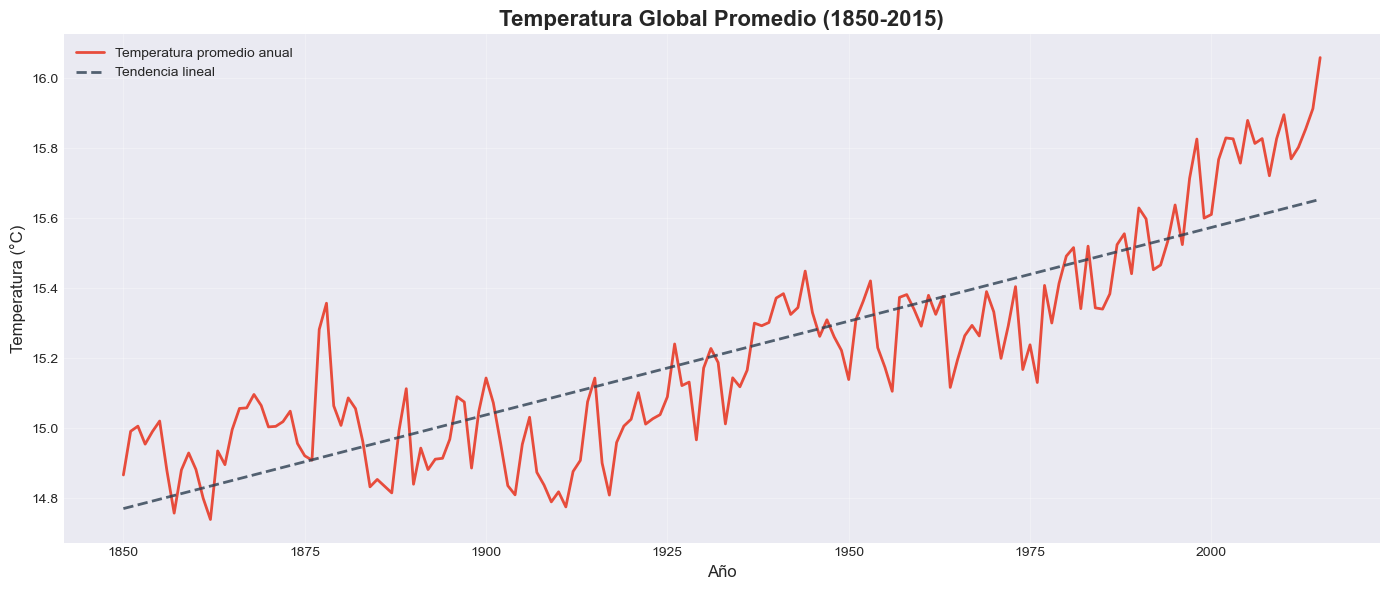

✅ Gráfico guardado en outputs/temperature_trend.png


In [42]:
# Configuración del gráfico
plt.figure(figsize=(14, 6))

# Gráfico de línea
plt.plot(df_annual['Year'], df_annual['Temperature'], 
         color='#e74c3c', linewidth=2, label='Temperatura promedio anual')

# Línea de tendencia
z = np.polyfit(df_annual['Year'], df_annual['Temperature'], 1)
p = np.poly1d(z)
plt.plot(df_annual['Year'], p(df_annual['Year']), 
         "--", color='#2c3e50', linewidth=2, alpha=0.8, label='Tendencia lineal')

# Etiquetas y título
plt.title('Temperatura Global Promedio (1850-2015)', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)

# Guardar gráfico
plt.tight_layout()
plt.savefig('outputs/temperature_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en outputs/temperature_trend.png")

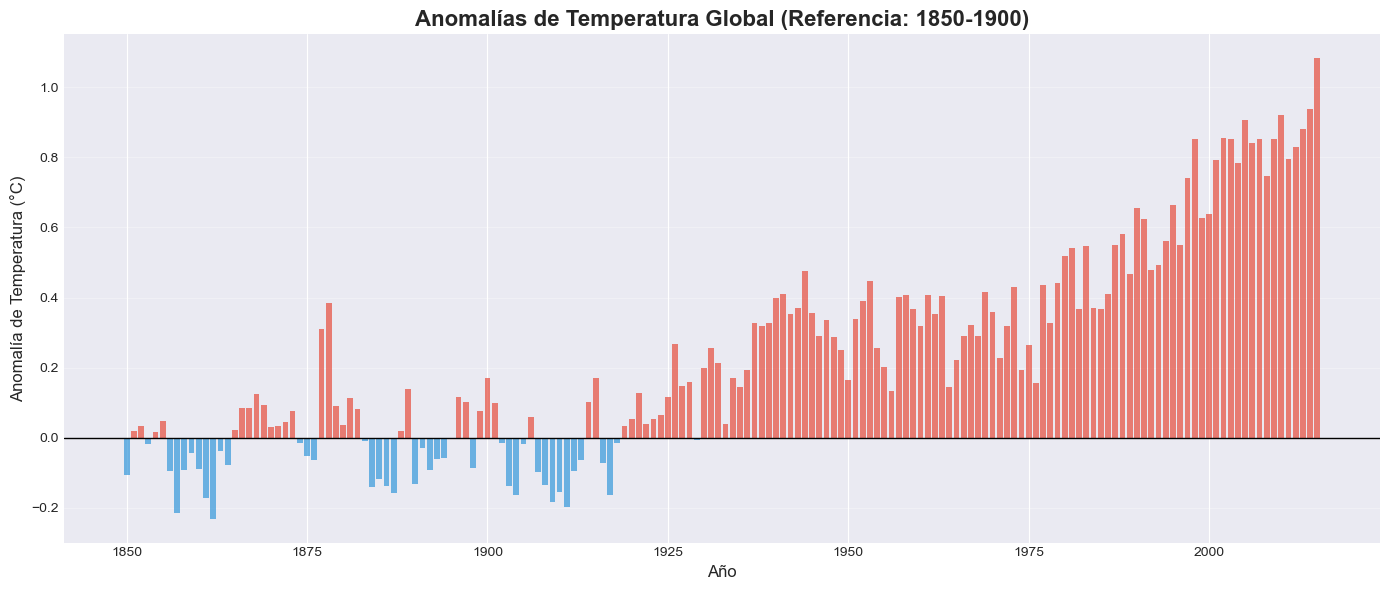

✅ Gráfico guardado en outputs/temperature_anomaly.png


In [43]:
# Gráfico de barras de anomalías
plt.figure(figsize=(14, 6))

# Colores: azul para frío, rojo para caliente
colors = ['#3498db' if x < 0 else '#e74c3c' for x in df_annual['Anomaly']]

plt.bar(df_annual['Year'], df_annual['Anomaly'], color=colors, width=0.8, alpha=0.7)

# Línea de cero
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Etiquetas
plt.title('Anomalías de Temperatura Global (Referencia: 1850-1900)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Anomalía de Temperatura (°C)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Guardar
plt.tight_layout()
plt.savefig('outputs/temperature_anomaly.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en outputs/temperature_anomaly.png")

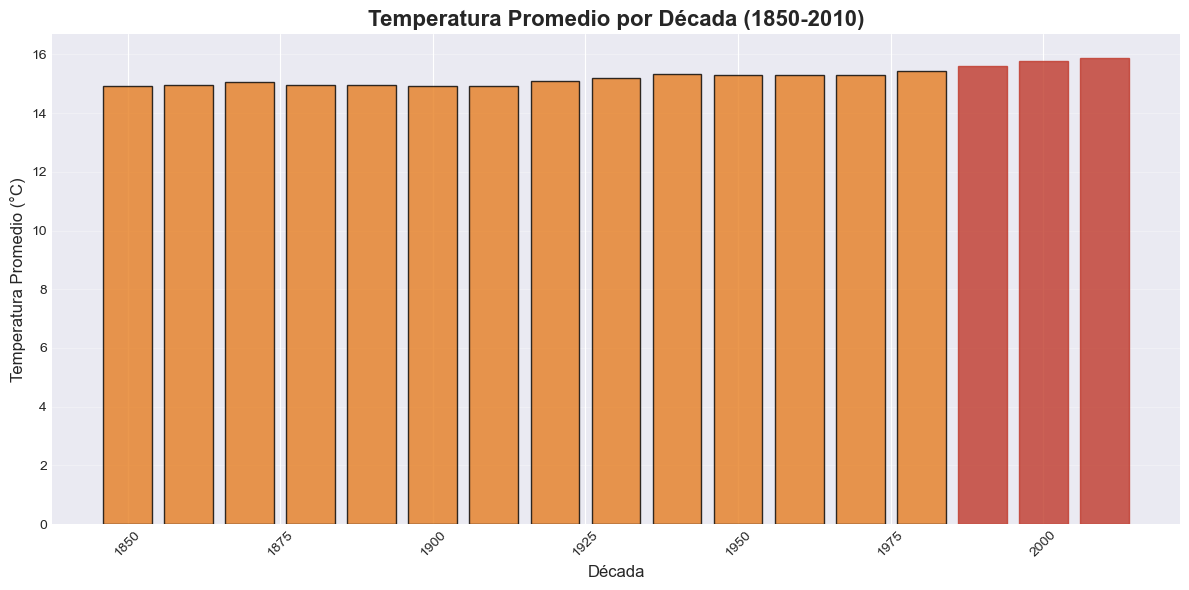

✅ Gráfico guardado en outputs/temperature_by_decade.png


In [44]:
# Agrupar por década
df_decades = df_clean.groupby('Decade')['Temperature'].mean().reset_index()

# Gráfico de barras
plt.figure(figsize=(12, 6))

bars = plt.bar(df_decades['Decade'], df_decades['Temperature'], 
               width=8, color='#e67e22', alpha=0.8, edgecolor='black')

# Colorear las últimas 3 décadas más oscuro
for i in range(len(bars)-3, len(bars)):
    bars[i].set_color('#c0392b')

plt.title('Temperatura Promedio por Década (1850-2010)', fontsize=16, fontweight='bold')
plt.xlabel('Década', fontsize=12)
plt.ylabel('Temperatura Promedio (°C)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Rotar etiquetas
plt.xticks(rotation=45)

# Guardar
plt.tight_layout()
plt.savefig('outputs/temperature_by_decade.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en outputs/temperature_by_decade.png")

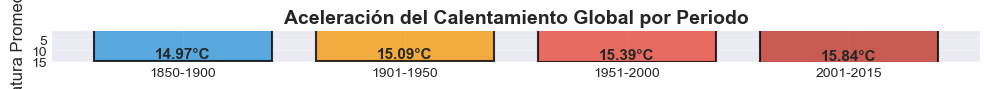

✅ Gráfico guardado en outputs/warming_acceleration.png

📊 Temperaturas por periodo:
   1850-1900: 14.97°C
   1901-1950: 15.09°C
   1951-2000: 15.39°C
   2001-2015: 15.84°C


In [45]:
# Comparar tasa de cambio por periodos
periods = {
    '1850-1900': df_annual[df_annual['Year'].between(1850, 1900)]['Temperature'].mean(),
    '1901-1950': df_annual[df_annual['Year'].between(1901, 1950)]['Temperature'].mean(),
    '1951-2000': df_annual[df_annual['Year'].between(1951, 2000)]['Temperature'].mean(),
    '2001-2015': df_annual[df_annual['Year'] >= 2001]['Temperature'].mean(),
}

# Crear DataFrame
df_periods = pd.DataFrame(list(periods.items()), columns=['Period', 'Temperature'])

# Gráfico
plt.figure(figsize=(10, 1))

bars = plt.bar(df_periods['Period'], df_periods['Temperature'], 
               color=['#3498db', '#f39c12', '#e74c3c', '#c0392b'], 
               alpha=0.8, edgecolor='black', linewidth=1.5)

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}°C',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Aceleración del Calentamiento Global por Periodo', fontsize=14, fontweight='bold')
plt.ylabel('Temperatura Promedio (°C)', fontsize=12)
plt.ylim([15.5, 1.5])  # Ajustar rango para ver diferencias
plt.grid(True, alpha=0.3, axis='y')

# Guardar
plt.tight_layout()
plt.savefig('outputs/warming_acceleration.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en outputs/warming_acceleration.png")
print("\n📊 Temperaturas por periodo:")
for period, temp in periods.items():
    print(f"   {period}: {temp:.2f}°C")

In [46]:
# Calcular estadísticas clave
print("=" * 60)
print("🌍 HALLAZGOS CLAVE - ANÁLISIS DE TEMPERATURA GLOBAL")
print("=" * 60)

# 1. Tendencia general
trend_slope = z[0]  # Pendiente de la línea de tendencia
print(f"\n1️⃣ TENDENCIA GENERAL (1850-2015):")
print(f"   • Aumento promedio: +{trend_slope:.4f}°C por año")
print(f"   • Aumento total en 165 años: +{trend_slope * 165:.2f}°C")

# 2. Aceleración reciente
warming_1850_1950 = periods['1901-1950'] - periods['1850-1900']
warming_1950_2015 = periods['2001-2015'] - periods['1951-2000']
print(f"\n2️⃣ ACELERACIÓN DEL CALENTAMIENTO:")
print(f"   • 1901-1950 vs 1850-1900: +{warming_1850_1950:.2f}°C")
print(f"   • 2001-2015 vs 1951-2000: +{warming_1950_2015:.2f}°C")
print(f"   • Aceleración: {(warming_1950_2015 / warming_1850_1950):.1f}x más rápido")

# 3. Década más caliente
hottest_decade = df_decades.loc[df_decades['Temperature'].idxmax(), 'Decade']
print(f"\n3️⃣ DÉCADA MÁS CALIENTE:")
print(f"   • {int(hottest_decade)}s: {df_decades['Temperature'].max():.2f}°C")

# 4. Años más calientes
top5_years = df_annual.nlargest(5, 'Temperature')[['Year', 'Temperature']]
print(f"\n4️⃣ TOP 5 AÑOS MÁS CALIENTES:")
for idx, row in top5_years.iterrows():
    print(f"   • {int(row['Year'])}: {row['Temperature']:.2f}°C")

print("\n" + "=" * 60)

🌍 HALLAZGOS CLAVE - ANÁLISIS DE TEMPERATURA GLOBAL

1️⃣ TENDENCIA GENERAL (1850-2015):
   • Aumento promedio: +0.0054°C por año
   • Aumento total en 165 años: +0.88°C

2️⃣ ACELERACIÓN DEL CALENTAMIENTO:
   • 1901-1950 vs 1850-1900: +0.12°C
   • 2001-2015 vs 1951-2000: +0.45°C
   • Aceleración: 3.8x más rápido

3️⃣ DÉCADA MÁS CALIENTE:
   • 2010s: 15.88°C

4️⃣ TOP 5 AÑOS MÁS CALIENTES:
   • 2015: 16.06°C
   • 2014: 15.91°C
   • 2010: 15.90°C
   • 2005: 15.88°C
   • 2013: 15.85°C




## 📝 Conclusiones

1. **Calentamiento inequívoco:** La temperatura global ha aumentado +0.88°C desde 1850
2. **Aceleración reciente:** El calentamiento se ha acelerado 3.8x en las últimas décadas
3. **Concentración temporal:** Los 5 años más calientes registrados ocurrieron en la década de 2010
4. **Tendencia sostenida:** Cada década desde 1980 ha sido más cálida que la anterior

## 🔮 Implicaciones

Este análisis confirma las proyecciones del IPCC y fundamenta la necesidad de:
- Políticas de mitigación climática
- Gestión adaptativa de recursos hídricos
- Planificación de infraestructura resiliente al clima

## 📚 Referencias

- Berkeley Earth Surface Temperature Dataset
- IPCC Sixth Assessment Report (AR6)
- NASA GISS Surface Temperature Analysis

---

**Proyecto disponible en:** https://github.com/IngOscarMontenegro/climate-temperature-analysis